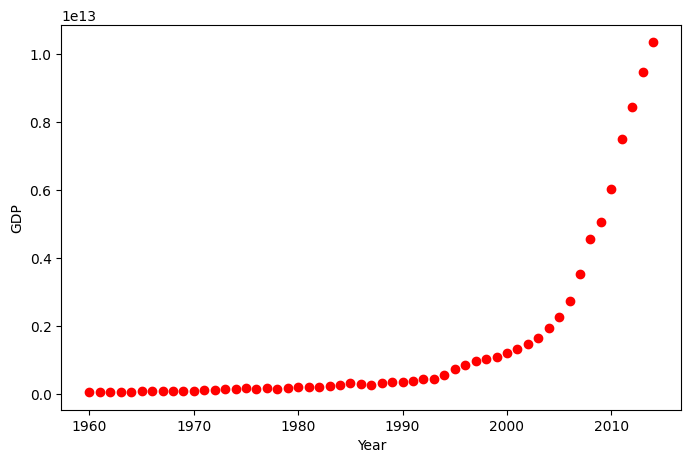

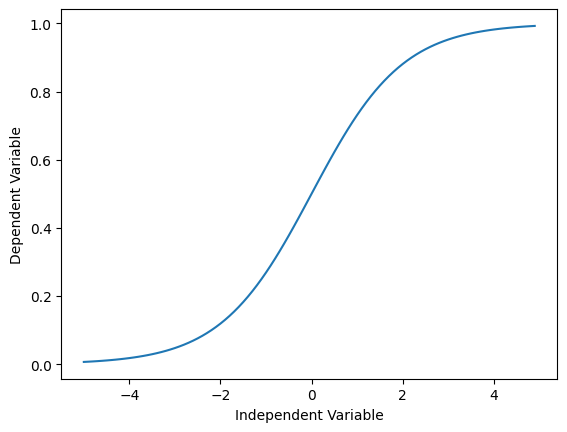

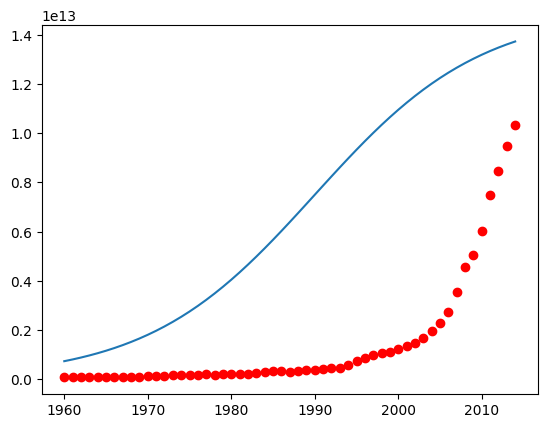

Sigmoid params: beta_1 = 690.451708, beta_2 = 0.997207


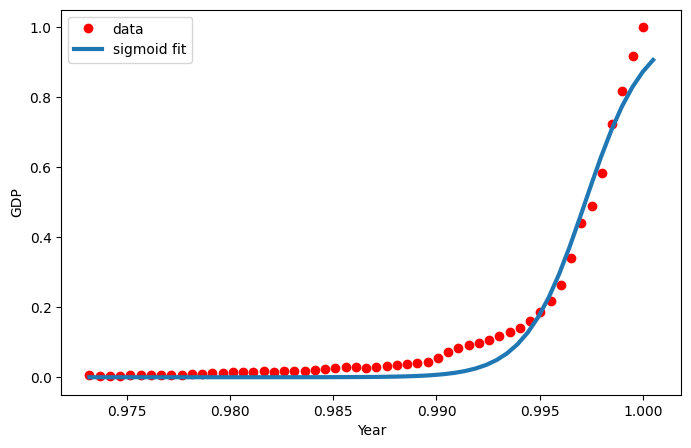

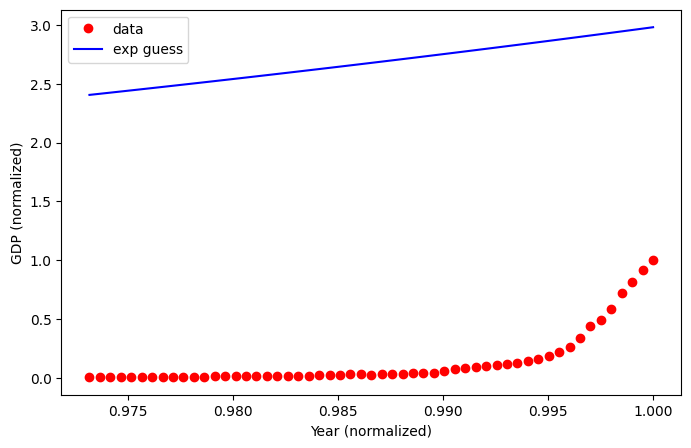

Exponential params: a = 0.000000, b = 20.000000


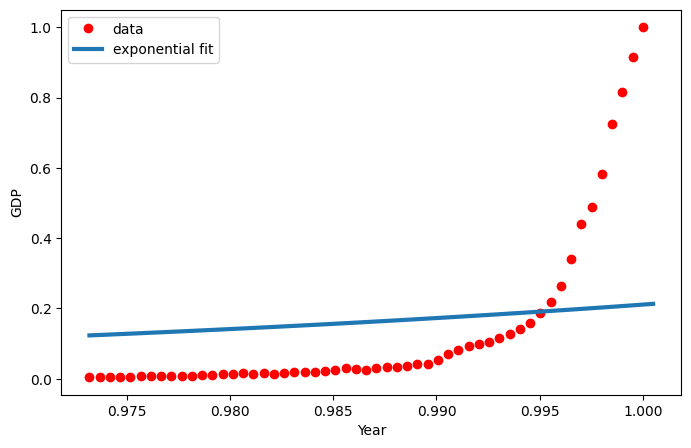


=== Метрики (чем меньше MAE/RMSE, тем лучше; чем больше R2, тем лучше) ===
Sigmoid     -> MAE: 0.030495, RMSE: 0.039452, R2: 0.972805
Exponential -> MAE: 0.161860, RMSE: 0.221636, R2: 0.141729

Лучшая модель по метрикам: Sigmoid (логистическая)


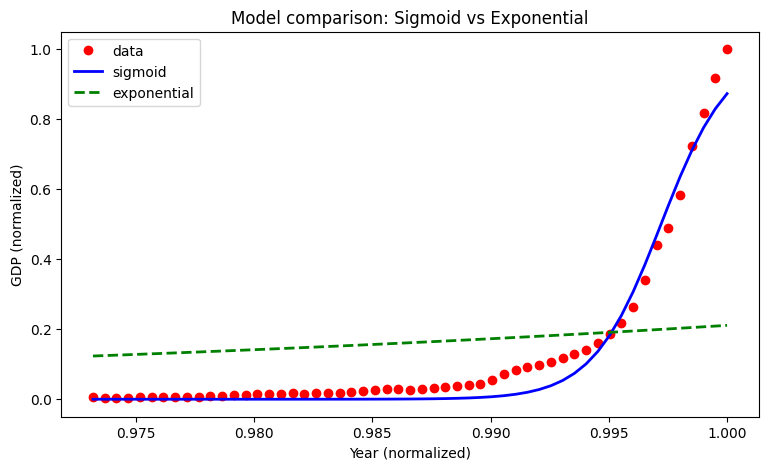

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("/home/jupyter/work/data/china_gdp.csv")
df.head(10)

plt.figure(figsize=(8,5))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, 'ro')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

X = np.arange(-5.0, 5.0, 0.1)
Y = 1.0 / (1.0 + np.exp(-X))

plt.plot(X, Y)
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

def sigmoid(x, Beta_1, Beta_2):
    y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
    return y

beta_1 = 0.10
beta_2 = 1990.0

Y_pred = sigmoid(x_data, beta_1, beta_2)

plt.plot(x_data, Y_pred*15000000000000.)
plt.plot(x_data, y_data, 'ro')
plt.show()

xdata = x_data / max(x_data)
ydata = y_data / max(y_data)

from scipy.optimize import curve_fit
popt_sig, pcov_sig = curve_fit(sigmoid, xdata, ydata)
print("Sigmoid params: beta_1 = %f, beta_2 = %f" % (popt_sig[0], popt_sig[1]))

x = np.linspace(1960, 2015, 55)
x = x / max(x_data)
y_sig = sigmoid(x, *popt_sig)

plt.figure(figsize=(8,5))
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x, y_sig, linewidth=3.0, label='sigmoid fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()


def exponential(x, a, b):
    return a * np.exp(b * x)

a0 = 0.001
b0 = 8.0
y_exp_guess = exponential(xdata, a0, b0)

plt.figure(figsize=(8,5))
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(xdata, y_exp_guess, 'b-', label='exp guess')
plt.legend(loc='best')
plt.ylabel('GDP (normalized)')
plt.xlabel('Year (normalized)')
plt.show()

popt_exp, pcov_exp = curve_fit(
    exponential, xdata, ydata,
    p0=[0.001, 8.0],
    bounds=([0, 0], [10, 20]),
    maxfev=10000
)

print("Exponential params: a = %f, b = %f" % (popt_exp[0], popt_exp[1]))

y_exp = exponential(x, *popt_exp)

plt.figure(figsize=(8,5))
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x, y_exp, linewidth=3.0, label='exponential fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

y_hat_sig = sigmoid(xdata, *popt_sig)
y_hat_exp = exponential(xdata, *popt_exp)

def metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return mae, rmse, r2

mae_sig, rmse_sig, r2_sig = metrics(ydata, y_hat_sig)
mae_exp, rmse_exp, r2_exp = metrics(ydata, y_hat_exp)

print("\n=== Метрики (чем меньше MAE/RMSE, тем лучше; чем больше R2, тем лучше) ===")
print("Sigmoid     -> MAE: %.6f, RMSE: %.6f, R2: %.6f" % (mae_sig, rmse_sig, r2_sig))
print("Exponential -> MAE: %.6f, RMSE: %.6f, R2: %.6f" % (mae_exp, rmse_exp, r2_exp))

if (rmse_sig < rmse_exp) and (r2_sig > r2_exp):
    best = "Sigmoid (логистическая)"
elif (rmse_exp < rmse_sig) and (r2_exp > r2_sig):
    best = "Exponential (экспоненциальная)"
else:
    best = "Sigmoid (логистическая)" if rmse_sig < rmse_exp else "Exponential (экспоненциальная)"

print("\nЛучшая модель по метрикам:", best)


plt.figure(figsize=(9,5))
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(xdata, y_hat_sig, 'b-', linewidth=2, label='sigmoid')
plt.plot(xdata, y_hat_exp, 'g--', linewidth=2, label='exponential')
plt.legend(loc='best')
plt.ylabel('GDP (normalized)')
plt.xlabel('Year (normalized)')
plt.title('Model comparison: Sigmoid vs Exponential')
plt.show()